In [1]:
!pip install PyWavelets -q

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pywt
import tensorflow as tf


from google.colab import files
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tensorflow.keras import layers, models

In [3]:
uploaded = files.upload()

Saving 2class_MI_EEG_test_9.csv to 2class_MI_EEG_test_9.csv
Saving 2class_MI_EEG_train_9.csv to 2class_MI_EEG_train_9.csv
Saving MI-EEG-B9E.csv to MI-EEG-B9E.csv
Saving MI-EEG-B9T.csv to MI-EEG-B9T.csv


In [4]:
X_train_raw = pd.read_csv("MI-EEG-B9T.csv", header=None)
X_test_raw = pd.read_csv("MI-EEG-B9E.csv", header=None)

y_train = pd.read_csv("2class_MI_EEG_train_9.csv", header=None).values.ravel()
y_test = pd.read_csv("2class_MI_EEG_test_9.csv", header=None).values.ravel()

print("X_train shape:", X_train_raw.shape)
print("X_test shape:", X_test_raw.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("Train labels:", np.unique(y_train, return_counts=True))
print("Test labels:", np.unique(y_test, return_counts=True))

X_train shape: (400, 3000)
X_test shape: (320, 3000)
y_train shape: (400,)
y_test shape: (320,)
Train labels: (array([0, 1]), array([200, 200]))
Test labels: (array([0, 1]), array([160, 160]))


In [5]:
print("Before:", np.unique(y_train), np.unique(y_test))

if set(np.unique(y_train)) == {1, 2}:
    y_train = y_train - 1

if set(np.unique(y_test)) == {1, 2}:
    y_test = y_test - 1

print("After:", np.unique(y_train), np.unique(y_test))

Before: [0 1] [0 1]
After: [0 1] [0 1]


In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_raw.values)
X_test_scaled = scaler.transform(X_test_raw.values)

print("Scaled train shape:", X_train_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

Scaled train shape: (400, 3000)
Scaled test shape: (320, 3000)


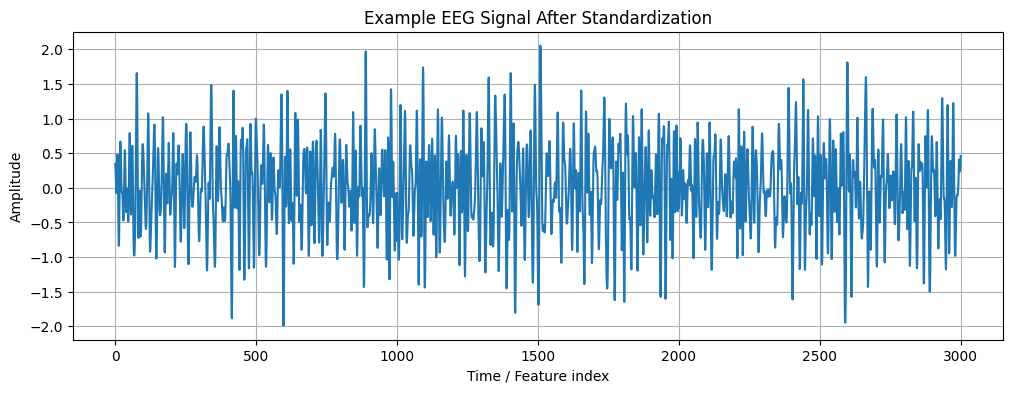

In [7]:
plt.figure(figsize=(12, 4))
plt.plot(X_train_scaled[0])
plt.title("Example EEG Signal After Standardization")
plt.xlabel("Time / Feature index")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

In [20]:
def signal_to_cwt_image(signal):
    # 只取前512个点，避免图像过大
    signal = signal[:512]

    # 尺度从64降到16
    scales = np.arange(1, 17)

    coefficients, frequencies = pywt.cwt(signal, scales, "morl")
    image = np.abs(coefficients)

    image = (image - image.min()) / (image.max() - image.min() + 1e-8)

    return image


In [21]:
X_train_cwt = np.array([signal_to_cwt_image(x) for x in X_train_scaled])
X_test_cwt = np.array([signal_to_cwt_image(x) for x in X_test_scaled])

print("CWT train shape:", X_train_cwt.shape)
print("CWT test shape:", X_test_cwt.shape)

CWT train shape: (400, 16, 512)
CWT test shape: (320, 16, 512)


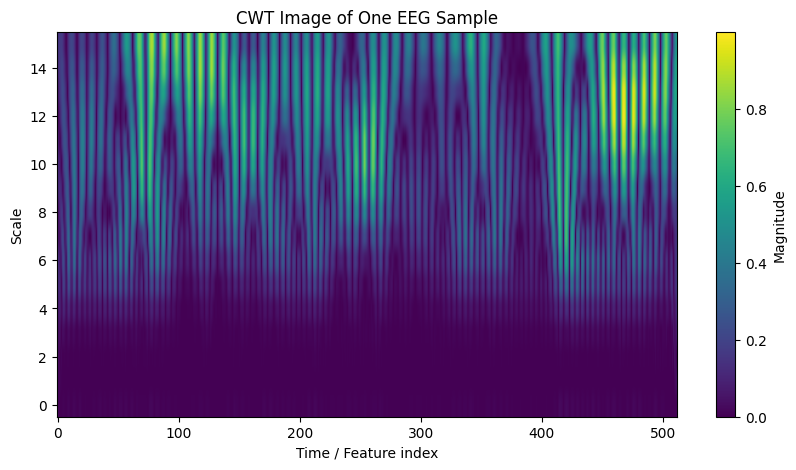

In [22]:
plt.figure(figsize=(10, 5))
plt.imshow(X_train_cwt[0], aspect="auto", origin="lower")
plt.title("CWT Image of One EEG Sample")
plt.xlabel("Time / Feature index")
plt.ylabel("Scale")
plt.colorbar(label="Magnitude")
plt.show()

In [23]:
X_train_cnn = X_train_cwt[..., np.newaxis]
X_test_cnn = X_test_cwt[..., np.newaxis]

print("CNN train shape:", X_train_cnn.shape)
print("CNN test shape:", X_test_cnn.shape)


CNN train shape: (400, 16, 512, 1)
CNN test shape: (320, 16, 512, 1)


In [25]:
input_shape = X_train_cnn.shape[1:]

model = models.Sequential([
    layers.Input(shape=input_shape),

    layers.Conv2D(8, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(16, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)




In [13]:
# train

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

history = model.fit(
    X_train_cnn,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 69s 3s/step - accuracy: 0.5094 - loss: 0.7422 - val_accuracy: 0.5000 - val_loss: 0.6929
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 81s 3s/step - accuracy: 0.5000 - loss: 0.6927 - val_accuracy: 0.5000 - val_loss: 0.6909
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 81s 4s/step - accuracy: 0.5719 - loss: 0.6882 - val_accuracy: 0.5000 - val_loss: 0.6877
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 69s 3s/step - accuracy: 0.5625 - loss: 0.6835 - val_accuracy: 0.6000 - val_loss: 0.6754
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 66s 3s/step - accuracy: 0.6219 - loss: 0.6474 - val_accuracy: 0.7875 - val_loss: 0.5724
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.6812 - loss: 0.5818 - val_accuracy: 0.7625 - val_loss: 0.5453
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 66s 3s/step - accuracy: 0.7188 - loss: 0.5424 - val_accuracy: 0.7625 - val_loss: 0.4985
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 66s 3s/step - accuracy: 0.7531 - loss: 0.4966 - val_accuracy: 0.7500 - val_loss:

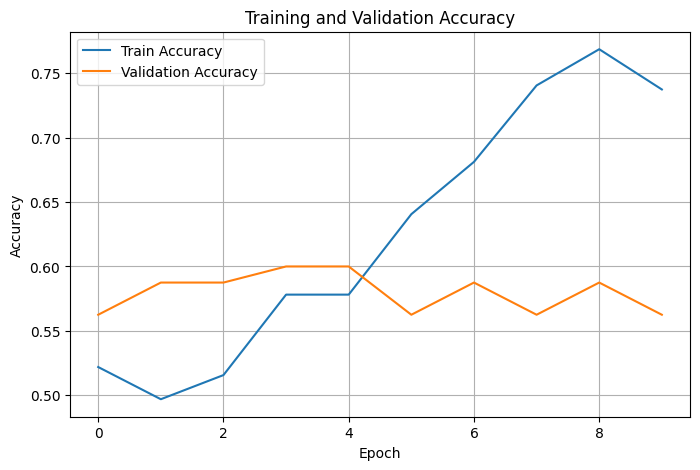

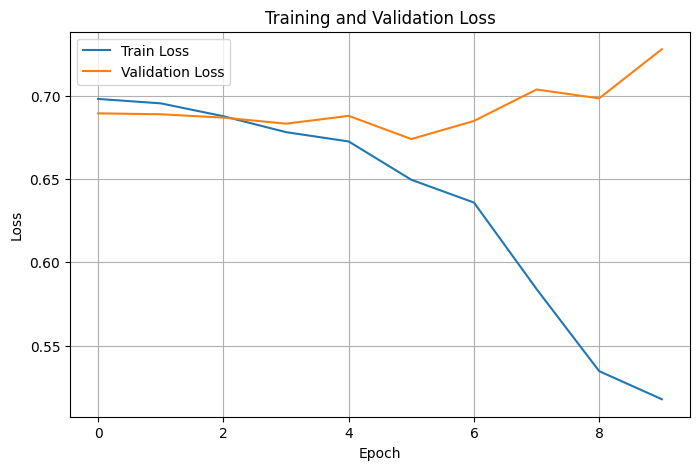

In [26]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


In [28]:
test_loss, test_accuracy = model.evaluate(X_test_cnn, y_test, verbose=0)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)


Test Loss: 0.6936410665512085
Test Accuracy: 0.5093749761581421


In [29]:
import gc

preds = []

batch_size = 4

for start in range(0, len(X_test_cnn), batch_size):
    end = start + batch_size
    batch = X_test_cnn[start:end]

    pred_batch = model(batch, training=False).numpy()
    preds.append(pred_batch)

    gc.collect()

y_pred_prob = np.vstack(preds).ravel()
y_pred = (y_pred_prob >= 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(cm)


Accuracy: 0.509375
              precision    recall  f1-score   support

           0       0.64      0.04      0.08       160
           1       0.50      0.97      0.67       160

    accuracy                           0.51       320
   macro avg       0.57      0.51      0.37       320
weighted avg       0.57      0.51      0.37       320

Confusion Matrix:
[[  7 153]
 [  4 156]]


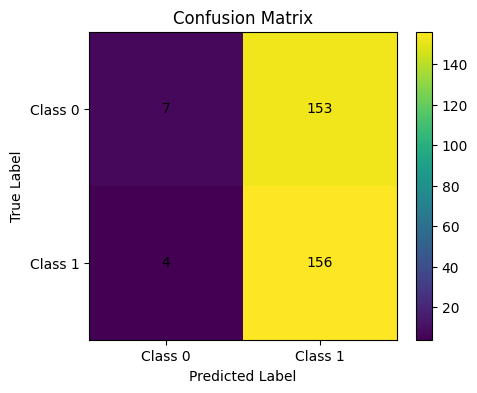

In [30]:
plt.figure(figsize=(5, 4))
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xticks([0, 1], ["Class 0", "Class 1"])
plt.yticks([0, 1], ["Class 0", "Class 1"])
plt.show()


In [18]:
num_samples = 10
indices = np.random.choice(len(X_test_cnn), num_samples, replace=False)

for idx in indices:
    true_label = y_test[idx]
    pred_label = y_pred[idx]
    prob = y_pred_prob[idx][0]
    print(f"Sample {idx}: True = {true_label}, Pred = {pred_label}, Probability = {prob:.4f}")


Sample 14: True = 1, Pred = 1, Probability = 0.7622
Sample 312: True = 1, Pred = 1, Probability = 0.5042
Sample 224: True = 1, Pred = 0, Probability = 0.1515
Sample 135: True = 1, Pred = 1, Probability = 0.6938
Sample 258: True = 0, Pred = 0, Probability = 0.4260
Sample 133: True = 1, Pred = 1, Probability = 0.7321
Sample 214: True = 0, Pred = 1, Probability = 0.5132
Sample 297: True = 1, Pred = 0, Probability = 0.4518
Sample 275: True = 1, Pred = 0, Probability = 0.3642
Sample 44: True = 0, Pred = 0, Probability = 0.1447


In [19]:
model.save("lab5_eeg_cnn_model.h5")
print("Model saved as lab5_eeg_cnn_model.h5")


Model saved as lab5_eeg_cnn_model.h5
